# Fake News Detection using Machine Learning

## Project Overview

Fake news has become a major challenge because misleading or false
information can spread quickly through online platforms. The aim of this
project is to develop a machine learning system that can classify a news
article as Fake or Real based on its textual content and other available
information.

## Objectives

- Load and analyze a real-world fake news dataset.
- Clean and preprocess news articles.
- Extract useful textual features using NLP techniques.
- Train multiple machine learning classification models.
- Compare the performance of different models.
- Evaluate the final model using standard classification metrics.
- Build a simple system that predicts whether new news text is Fake or Real.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- NLP
- TF-IDF
- Google Colab

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [8]:
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

In [9]:
print("Fake News Shape:", fake_df.shape)
print("Real News Shape:", true_df.shape)

Fake News Shape: (23481, 4)
Real News Shape: (21417, 4)


In [10]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [12]:
fake_df["label"] = 0
true_df["label"] = 1

In [13]:
df = pd.concat(
    [fake_df, true_df],
    axis=0,
    ignore_index=True
)

In [14]:
print("Combined Dataset Shape:", df.shape)

Combined Dataset Shape: (44898, 5)


In [15]:
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [16]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [17]:
print(df.columns.tolist())

['title', 'text', 'subject', 'date', 'label']


In [18]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [19]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing

,Missing Values,Percentage
title,0,0.0
text,0,0.0
subject,0,0.0
date,0,0.0
label,0,0.0


In [20]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 209


In [21]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (44689, 5)


In [22]:
print(df["label"].value_counts())

label
0    23478
1    21211
Name: count, dtype: int64


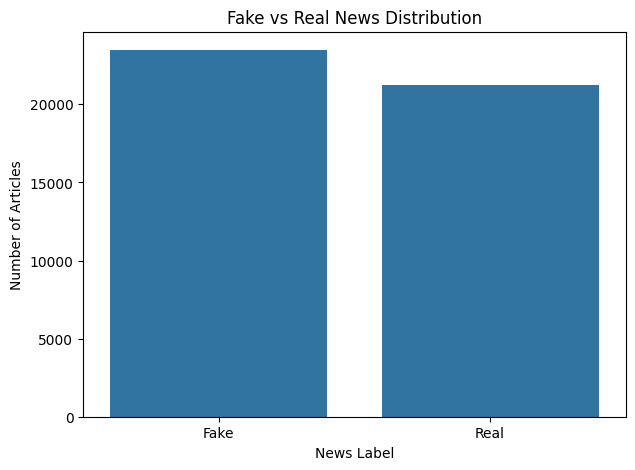

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Fake vs Real News Distribution")
plt.xlabel("News Label")
plt.ylabel("Number of Articles")

plt.xticks(
    [0, 1],
    ["Fake", "Real"]
)

plt.show()

In [24]:
print(df["subject"].value_counts())

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


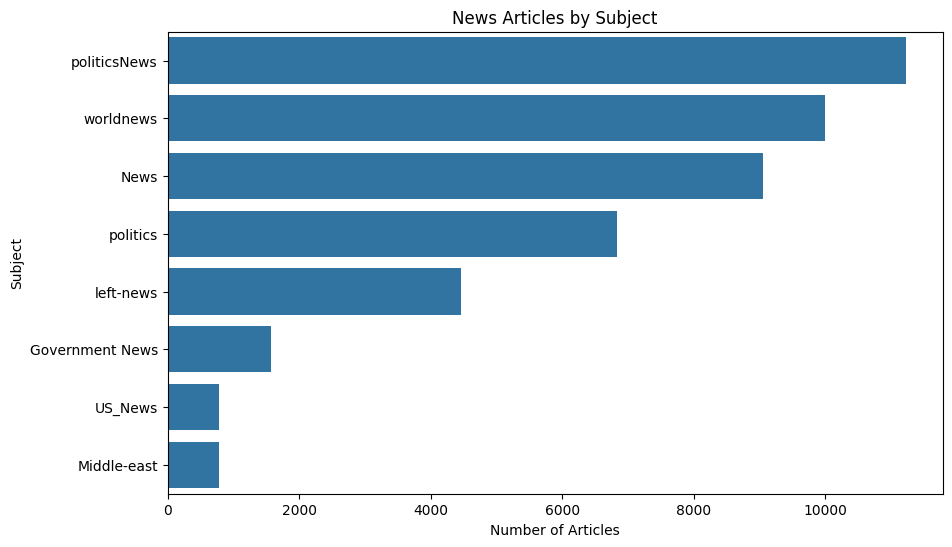

In [25]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="subject",
    order=df["subject"].value_counts().index
)

plt.title("News Articles by Subject")
plt.xlabel("Number of Articles")
plt.ylabel("Subject")

plt.show()

In [26]:
df["title_length"] = df["title"].fillna("").apply(len)

df["text_length"] = df["text"].fillna("").apply(len)

df["word_count"] = df["text"].fillna("").apply(
    lambda x: len(x.split())
)

In [27]:
df[
    [
        "title",
        "title_length",
        "text_length",
        "word_count",
        "label"
    ]
].head()

,title,title_length,text_length,word_count,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,89,1028,171,0
1,Trump drops Steve Bannon from National Securit...,55,4820,771,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,64,1848,304,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,89,1244,183,0
4,Donald Trump heads for Scotland to reopen a go...,55,3137,529,1


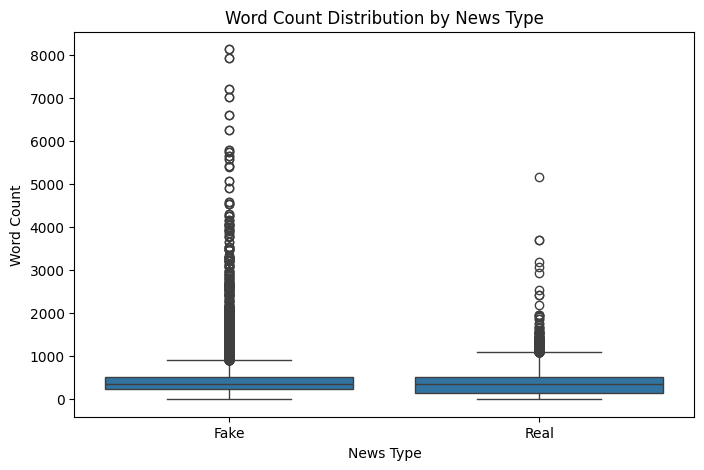

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="word_count"
)

plt.title("Word Count Distribution by News Type")
plt.xlabel("News Type")
plt.ylabel("Word Count")

plt.xticks(
    [0, 1],
    ["Fake", "Real"]
)

plt.show()

In [29]:
df["combined_text"] = (
    df["title"].fillna("") +
    " " +
    df["text"].fillna("")
)

In [30]:
df[
    ["title", "text", "combined_text", "label"]
].head(2)

,title,text,combined_text,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,Trump drops Steve Bannon from National Securit...,1


# now we did text processing..

In [31]:
def clean_text(text):
    text = str(text)

    text = text.lower()

    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [32]:
df["clean_text"] = df["combined_text"].apply(clean_text)

In [33]:
df[
    ["combined_text", "clean_text", "label"]
].head(3)

,combined_text,clean_text,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein calls out th circuit court committed...,0
1,Trump drops Steve Bannon from National Securit...,trump drops steve bannon from national securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects us to lift jones act shipp...,1


In [34]:
df.to_csv(
    "fake_news_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


TF-IDF = Term Frequency–Inverse Document Frequency

It gives higher importance to words that are useful for distinguishing documents and lower importance to words that occur very commonly across many documents.

In [35]:
X = df["clean_text"]
y = df["label"]

print("Number of articles:", len(X))
print("Target values:")
print(y.value_counts())

Number of articles: 44689
Target values:
label
0    23478
1    21211
Name: count, dtype: int64


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training articles:", len(X_train))
print("Testing articles:", len(X_test))

Training articles: 35751
Testing articles: 8938


In [37]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

In [44]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [45]:
X_test_tfidf = tfidf.transform(X_test)

In [46]:
print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape:", X_test_tfidf.shape)

Training Shape: (35751, 5000)
Testing Shape: (8938, 5000)


In [47]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['abandon' 'abandoned' 'abbas' 'abc' 'abdullah' 'abe' 'abedin' 'ability'
 'able' 'abortion' 'abortions' 'abroad' 'absence' 'absolute' 'absolutely'
 'absurd' 'abu' 'abuse' 'abused' 'abuses' 'academic' 'academy' 'accept'
 'acceptable' 'accepted' 'accepting' 'access' 'accident' 'accompanied'
 'accord' 'according' 'account' 'accountability' 'accountable' 'accounts'
 'accurate' 'accusation' 'accusations' 'accuse' 'accused' 'accuses'
 'accusing' 'achieve' 'achieved' 'acknowledge' 'acknowledged' 'aclu' 'acr'
 'act' 'acted']


In [48]:
print(X_train.iloc[0])

sean hannity loses his sht after getting his ass handed to him by new york times writers it s time for sean hannity to join bill o reilly in the unemployment lineon saturday the new york times published an article reporting that donald trump gets policy advise from sean hannity among many others outside the white house sean hannity tells the president that keeping promises on core republican issues is crucial presidents always deploy surrogates to appear on television to spout their talking points but mr trump has expanded on that by developing relationships with sympathetic media figures like mr hannity who also serve as advisers mr hannity the fox news host defends mr trump s most controversial behavior in public but privately according to people close to mr trump he urges the president not to get distracted and advises him to focus on keeping pledges like repealing the affordable care act indeed hannity served as trump s chief propagandist during the campaign and often did interview

In [ ]:
print(X_train_tfidf[0])

In [49]:
sample_tfidf = X_train_tfidf[:5].toarray()

tfidf_sample_df = pd.DataFrame(
    sample_tfidf,
    columns=feature_names
)

tfidf_sample_df.iloc[:, :20]

,abandon,abandoned,abbas,abc,abdullah,abe,abedin,ability,able,abortion,abortions,abroad,absence,absolute,absolutely,absurd,abu,abuse,abused,abuses
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.056809,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000)

In [51]:
y_pred_lr = logistic_model.predict(
    X_test_tfidf
)

In [52]:
print(y_pred_lr[:20])

[1 1 1 0 1 0 0 0 0 1 0 0 1 1 0 1 1 0 0 0]


In [53]:
accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.9875811143432536


In [54]:
print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Accuracy: 98.76 %


In [55]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Fake", "Real"]
    )
)

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.98      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



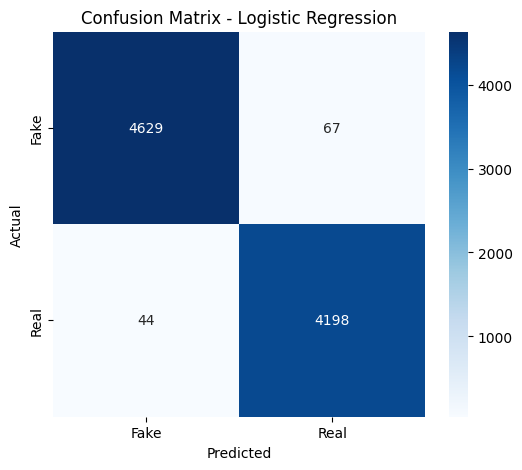

In [56]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()